In [34]:
import pennylane as qml
import torch
import matplotlib.pyplot as plt

from itertools import combinations
from pennylane import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset

In [35]:
SEED = 42 # For reproducibility
torch.manual_seed(SEED)

# Hybrid Quantum Neural Networks

So far, we have used the word hybrid to describe algorithms that combine classical and quantum computation, such as VQE, QAOA, QSVMs or QNN training. However, in this notebook we will use the term in a more specific way. A hybrid architecture refers to a model in which classical neural network layers and quantum neural network layers are connected and trained together as a single unit.

The main idea is to insert a quantum layer inside a classical neural network. This quantum layer receives a numerical array as input, usually coming from a previous classical layer, processes it through a parametrized quantum circuit, and returns a classical output obtained from quantum measurements. From the point of view of the next classical layer, the quantum layer behaves like an ordinary layer with a fixed number of output neurons.

A simple hybrid QNN could be structured as follows. First, the model receives a classical input vector. Then, one or more classical layers transform this input, possibly reducing its dimensionality. The resulting vector is passed to a quantum layer, where the data are encoded into a quantum state, processed by a variational circuit, and measured. Finally, the measured outputs can be passed to another classical layer to produce the final prediction.

This type of architecture is especially useful when the original dataset has more features than can be directly handled by a small quantum circuit. Instead of applying dimensionality reduction as a separate preprocessing step, a classical neural network can learn an internal representation of the data and feed it into the quantum layer. Since the whole model is trained jointly, both the classical and quantum parts contribute to the final task.

However, quantum layers should not be added blindly. They are not guaranteed to improve the performance of a classical model, and in some cases they may even make training harder. The design must be intentional: the number of qubits, the feature map, the variational ansatz, the measurement strategy and the connection with the classical layers all affect the model's behavior. For example, if the quantum feature map expects normalized inputs, the previous classical layer should use an activation function compatible with that range.

In this notebook, we will build and train hybrid quantum neural networks for classification tasks. The goal is to understand how classical and quantum layers can be combined, how the complete model is optimized, and whether the hybrid architecture can provide useful performance on real datasets.


# Binary classification problem

First, we will work on a binary classification problem using an artificial dataset generated by the function `make_clasiffication` from `sklearn.datasets`.

In [36]:
x, y = make_classification(n_samples=1000, n_features=20)

x_tr, x_test, y_tr, y_test = train_test_split(x, y, test_size=0.2)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5)

# Convert data to torch tensors
x_train_t = torch.from_numpy(x_tr).double()
y_train_t = torch.from_numpy(y_tr).double()

x_val_t = torch.from_numpy(x_val).double()
y_val_t = torch.from_numpy(y_val).double()

x_test_t = torch.from_numpy(x_test).double()
y_test_t = torch.from_numpy(y_test).double()

# Load data
train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

In [37]:
def TwoLocal(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a two-local variational ansatz using PennyLane.
    """
    # Initial rotation layer
    for i in range(nqubits):
        qml.RY(theta[i], wires=i)

    # Entangling and rotation layers
    for rep in range(reps):
        # Linear CNOT entanglement
        for i in range(nqubits-1):
            qml.CNOT(wires = [i, i+1])
        # New rotation layer
        for i in range(nqubits):
            qml.RY(theta[i+(rep+1)*nqubits], wires=i)

In [38]:
nqubits = 4
nreps = 2
dev = qml.device("lightning.qubit", wires=nqubits)

def qnn_circ(inputs: list[float], theta: list[float]) -> None:
    """
    Builds a QNN circuit in Pennylane using angle encoding, a Two local ansantz
    and the observable M = |0><0| for the measurement.
    """
    qml.AngleEmbedding(inputs, wires=range(nqubits))
    TwoLocal(nqubits, theta, nreps)
    return qml.expval(qml.Projector([0], wires=0))

qnn = qml.QNode(
    func=qnn_circ,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

In [43]:
weights = {"theta": ((nreps + 1) * nqubits,)}
qlayer = qml.qnn.TorchLayer(qnn, weights)

# Build the PyTorch model
model = torch.nn.Sequential(
    torch.nn.Linear(20, 16),
    torch.nn.Sigmoid(),
    torch.nn.Linear(16, 8),
    torch.nn.Sigmoid(),
    torch.nn.Linear(8, 4),
    torch.nn.Sigmoid(),
    qlayer
)

model.double()

# Training loop with early stopping
epochs = 100
lr = 0.005
patience = 4
patience_counter = 0
best_state = None
best_val_loss = float("inf")

# Define optimizer and loss function
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.BCELoss()

history = {"loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    loss_list = []
    for xb, yb in train_loader:
        opt.zero_grad()
        pred = model(xb).reshape(-1)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        loss_list.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        pred_val = model(x_val_t)
        val_loss = loss_fn(pred_val, y_val_t).item()
    
    loss = sum(loss_list) / len(loss_list)

    history["loss"].append(loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch + 1}: "
        f"loss={loss:.4f}, "
        f"val_loss={val_loss:.4f}"
    )

    if val_loss <= best_val_loss:
        best_val_loss = val_loss
        best_state = {
            name : param.detach().clone()
            for name, param in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early Stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 1: loss=0.6891, val_loss=0.6691
Epoch 2: loss=0.6277, val_loss=0.5744
Epoch 3: loss=0.5450, val_loss=0.5160
Epoch 4: loss=0.4945, val_loss=0.4736
Epoch 5: loss=0.4588, val_loss=0.4463
Epoch 6: loss=0.4348, val_loss=0.4311
Epoch 7: loss=0.4204, val_loss=0.4224
Epoch 8: loss=0.4143, val_loss=0.4209
Epoch 9: loss=0.4096, val_loss=0.4191
Epoch 10: loss=0.4143, val_loss=0.4152
Epoch 11: loss=0.4111, val_loss=0.4186
Epoch 12: loss=0.4090, val_loss=0.4128
Epoch 13: loss=0.4089, val_loss=0.4171
Epoch 14: loss=0.4086, val_loss=0.4194
Epoch 15: loss=0.4065, val_loss=0.4139
Epoch 16: loss=0.4061, val_loss=0.4125
Epoch 17: loss=0.4055, val_loss=0.4123
Epoch 18: loss=0.4039, val_loss=0.4125
Epoch 19: loss=0.4052, val_loss=0.4116
Epoch 20: loss=0.4043, val_loss=0.4153
Epoch 21: loss=0.4043, val_loss=0.4142
Epoch 22: loss=0.4030, val_loss=0.4145
Epoch 23: loss=0.4017, val_loss=0.4144
Early Stopping


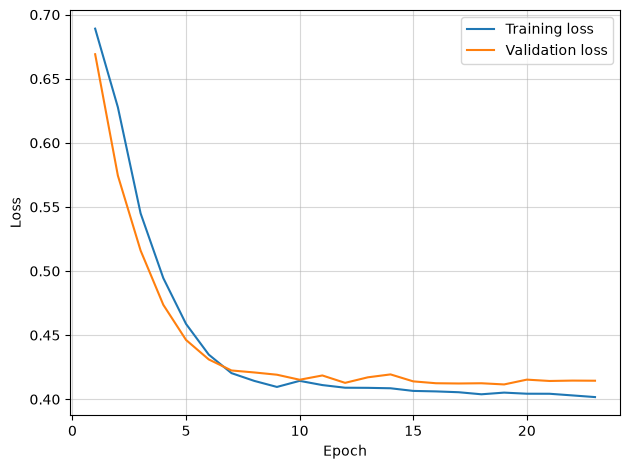

In [44]:
def plot_losses(history) -> None:
    """
    Plots the training and validation curves from the history of a model
    """
    tr_loss = history["loss"]
    val_loss = history["val_loss"]
    epochs = np.array(range(len(tr_loss))) + 1
    plt.plot(epochs, tr_loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_losses(history)

In [45]:
# Evaluate the precision of the model in all the datasets
model.eval()
with torch.no_grad():
    train_probs = model(x_train_t).squeeze()
    train_preds = (train_probs >= 0.5).double()
    train_acc = (train_preds == y_train_t).double().mean().item()

    val_probs = model(x_val_t).squeeze()
    val_preds = (val_probs >= 0.5).double()
    val_acc = (val_preds == y_val_t).double().mean().item()

    test_probs = model(x_test_t).squeeze()
    test_preds = (test_probs >= 0.5).double()
    test_acc = (test_preds == y_test_t).double().mean().item()

print(f"Train accuracy: {100*train_acc:.2f}%")
print(f"Val accuracy: {100*val_acc:.2f}%")
print(f"Test accuracy: {100*test_acc:.2f}%")

Train accuracy: 93.38%
Val accuracy: 93.00%
Test accuracy: 89.00%
